In [8]:
import os
import numpy as np
import h5py
from scipy import signal
from scipy.stats import pearsonr
import seaborn as sns
import datetime
import pandas as pd
import matplotlib.pyplot as plt
import string

# Define path to data:
script_dir = os.path.dirname(os.path.abspath("Figure 1 Data Summary.ipynb"))
parent_dir = os.path.dirname(script_dir)
data_path = os.path.join(parent_dir, 'dfs')


In [10]:
# Load questionnaires data file:
Quest_data = pd.read_csv(data_path+'/df_questionnaires.csv')
CSHQ_data = pd.read_csv(data_path+'/df_cshq_clean.csv')

# Merge the two dataframes:
Quest_data = Quest_data.merge(CSHQ_data, on='SPID', how='inner')  

print(len(Quest_data),len(CSHQ_data))

200 200


### Plot Questionnaires Scores Across Groups

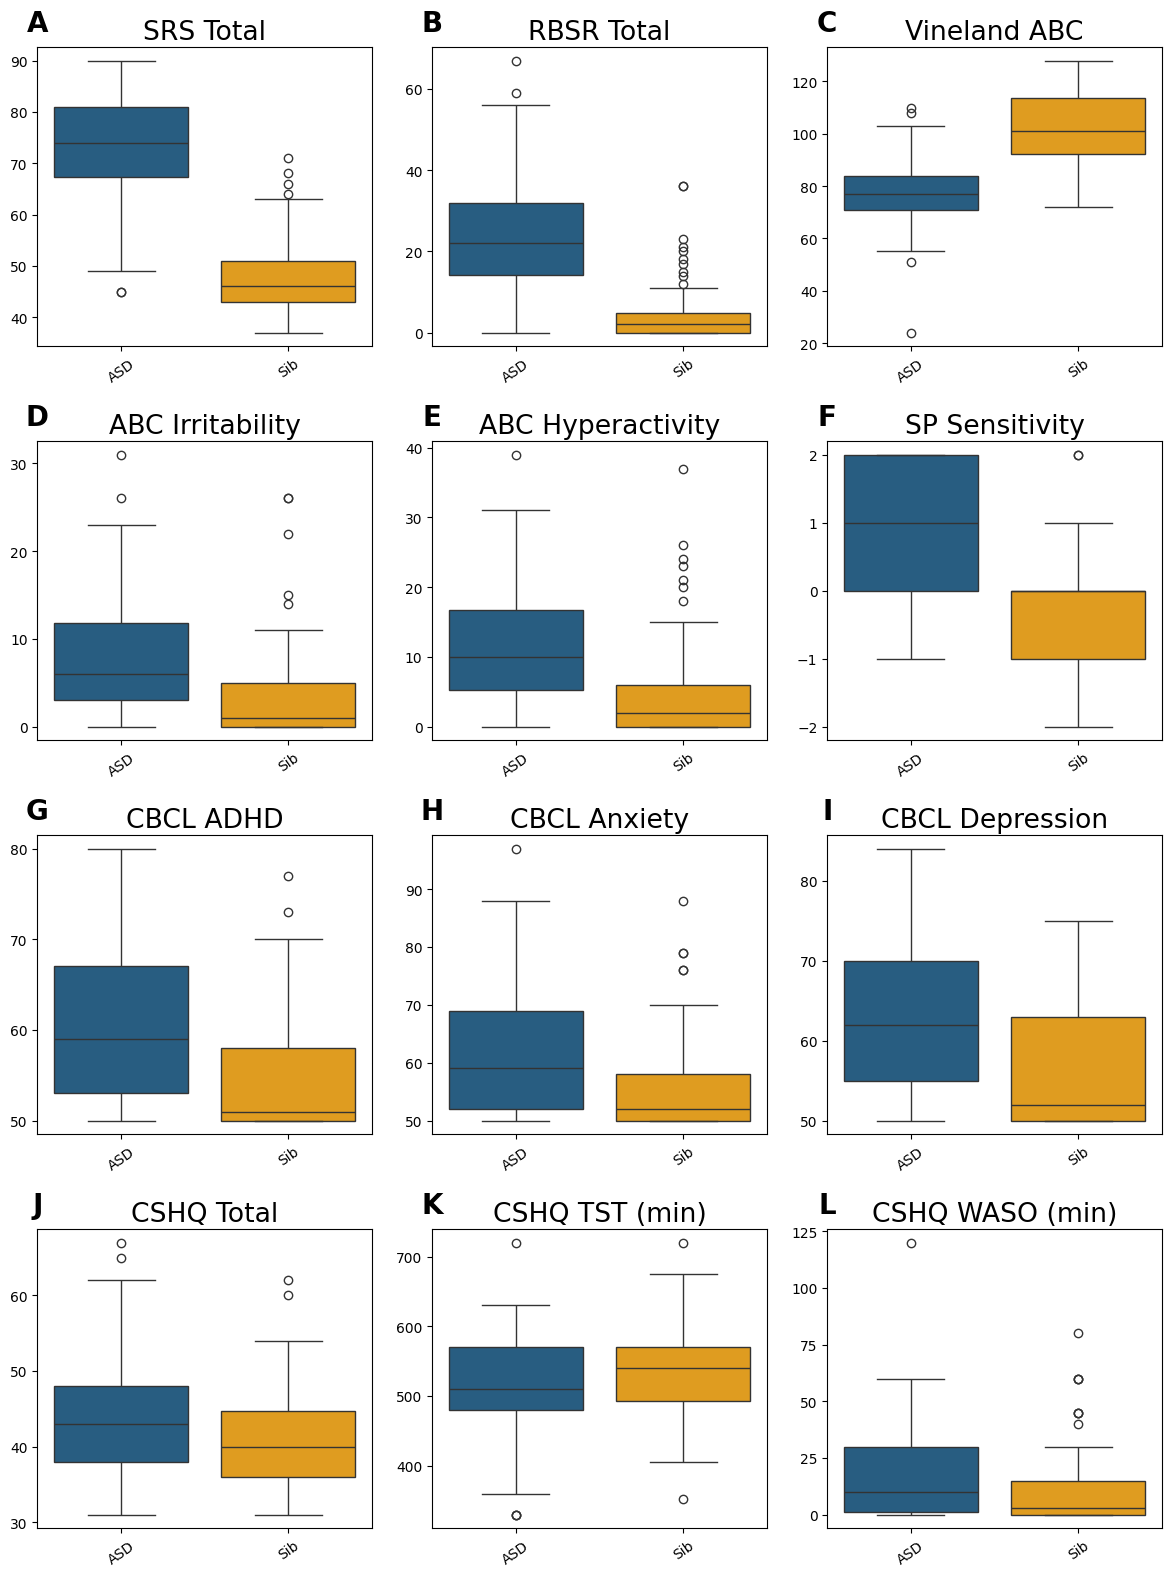

In [11]:
# Create a new column for the groups


Quest_data['Group'] = Quest_data.apply(lambda row: 'ASD' if row['asd'] else 'Sib', axis=1)

group_order = ['ASD', 'Sib']

# Define a color palette for the groups
hue_colors = {'ASD': '#19609080', 'Sib': '#FFA500'}

# List of metrics and titles
metrics = ['srs_total', 'rbsr_total', 'vineland_abc',
            'abc_irritability', 'abc_hyperactivity', 'sp_sensitivity_sd',
            'cbcl_dsm5_adhd', 'cbcl_dsm5_anxiety', 'cbcl_dsm5_depressive',
            'cshq_total', 'TST', 'WASO']
titles = ['SRS Total', 'RBSR Total', 'Vineland ABC',
            'ABC Irritability', 'ABC Hyperactivity', 'SP Sensitivity',
            'CBCL ADHD', 'CBCL Anxiety', 'CBCL Depression',
            'CSHQ Total', 'CSHQ TST (min)', 'CSHQ WASO (min)']

# Create a grid of subplots
fig, axes = plt.subplots(4, 3, figsize=(12, 16))

# Flatten the axes for easier iteration
axes = axes.flatten()
# Set global font size for the plot
plt.rcParams.update({'font.size': 16})


# Plot each metric
for i, metric in enumerate(metrics):
    sns.boxplot(x='Group', y=metric, data=Quest_data, order=group_order, ax=axes[i], hue='Group', dodge=False, palette=hue_colors)
    axes[i].set_title(titles[i])
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')
    axes[i].tick_params(axis='x', rotation=35)  # Rotate x-axis labels slightly for clarity
    # Add panel labels (A, B, C, ...)
    axes[i].text(0, 1.08, string.ascii_uppercase[i], transform=axes[i].transAxes,
                 fontsize=20, fontweight='bold', va='center', ha='center')

# Adjust layout and add more space between rows
plt.subplots_adjust(hspace=0.4)  # Increase vertical space between rows
plt.tight_layout()
plt.show()

### Preform mixed linear models analysis

In [17]:
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings("ignore")

# ── helpers ──────────────────────────────────────────────────────
def marginal_r2(res):
    var_fixed = np.var(res.fittedvalues, ddof=0)
    var_resid = res.scale
    return var_fixed / (var_fixed + var_resid)

def conditional_r2(res):
    var_fixed = np.var(res.fittedvalues, ddof=0)
    var_resid = res.scale
    var_random = float(res.cov_re.iloc[0, 0])
    return (var_fixed + var_random) / (var_fixed + var_random + var_resid)

def f2(r2_full, r2_red):
    return (r2_full - r2_red) / (1.0 - r2_full)

# ── data prep ─────────────────────────────────────────────────────
Quest_data.columns = [col.replace(" ", "_") for col in Quest_data.columns]
Quest_data = Quest_data.dropna(subset=['WASO', 'TST'])  # You can add more if needed

sleep_measures = [
    'srs_total', 'rbsr_total', 'vineland_abc',
    'abc_irritability', 'abc_hyperactivity', 'sp_sensitivity_sd',
    'cbcl_dsm5_adhd', 'cbcl_dsm5_anxiety', 'cbcl_dsm5_depressive',
    'cshq_total', 'TST', 'WASO'
]

# ── analysis loop ────────────────────────────────────────────────
all_results = []

for measure in sleep_measures:
    if measure not in Quest_data.columns:
        print(f"⚠️ {measure} not found – skipped")
        continue

    print(f"Analyzing {measure} with ASD, Sex, and Age as fixed effects...")

    base_formula = f"{measure} ~ asd + sex + age_months"
    try:
        # Full model
        full_mod = smf.mixedlm(base_formula, Quest_data, groups=Quest_data["Parent_RID"])
        full_res = full_mod.fit()

        r2_full = marginal_r2(full_res)
        rand_var = float(full_res.cov_re.iloc[0, 0])
        resid_var = full_res.scale
        icc = rand_var / (rand_var + resid_var)

        # Reduced model (excluding ASD)
        red_formula = base_formula.replace('asd + ', '')
        red_res = smf.mixedlm(red_formula, Quest_data, groups=Quest_data["Parent_RID"]).fit()
        r2_red = marginal_r2(red_res)
        f2_val = f2(r2_full, r2_red)

        # Append results
        all_results.append({
            "Measure"    : measure,
            "Between Var": rand_var,
            "Within Var" : resid_var,
            "ICC"        : icc,
            "marg_R²"    : r2_full,
            "ASD β"      : full_res.params.get('asd[T.True]', np.nan),
            "ASD p"      : full_res.pvalues.get('asd[T.True]', np.nan),
            "ASD f²"     : f2_val,
        })

    except Exception as e:
        print(f"  Error analyzing {measure}: {e}")

# ── Output ───────────────────────────────────────────────────────
results_df = pd.DataFrame(all_results)
print("\nSummary of mixed-model analysis:")
results_df = results_df.round(3)
print(results_df)


Analyzing srs_total with ASD, Sex, and Age as fixed effects...
Analyzing rbsr_total with ASD, Sex, and Age as fixed effects...
Analyzing vineland_abc with ASD, Sex, and Age as fixed effects...
Analyzing abc_irritability with ASD, Sex, and Age as fixed effects...
Analyzing abc_hyperactivity with ASD, Sex, and Age as fixed effects...
Analyzing sp_sensitivity_sd with ASD, Sex, and Age as fixed effects...
Analyzing cbcl_dsm5_adhd with ASD, Sex, and Age as fixed effects...
Analyzing cbcl_dsm5_anxiety with ASD, Sex, and Age as fixed effects...
Analyzing cbcl_dsm5_depressive with ASD, Sex, and Age as fixed effects...
Analyzing cshq_total with ASD, Sex, and Age as fixed effects...
Analyzing TST with ASD, Sex, and Age as fixed effects...
Analyzing WASO with ASD, Sex, and Age as fixed effects...

Summary of mixed-model analysis:
                 Measure  Between Var  Within Var    ICC  marg_R²   ASD β  \
0              srs_total       19.129      57.297  0.250    0.754  26.254   
1             r

In [18]:
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings("ignore")

# ── helpers 
def marginal_r2(res):
    """Nakagawa & Schielzeth (2013) marginal R²: var(fixed) / (var(fixed)+var(resid))"""
    var_fixed = np.var(res.fittedvalues)
    var_resid = res.scale
    return var_fixed / (var_fixed + var_resid)

def conditional_r2(res):
    """Conditional R²: (var(fixed)+var(random)) / total"""
    var_fixed = np.var(res.fittedvalues)
    var_resid = res.scale
    var_random = float(res.cov_re.iloc[0, 0])
    return (var_fixed + var_random) / (var_fixed + var_random + var_resid)

def f2(r2_full, r2_red):
    """Cohen's local effect size"""
    return (r2_full - r2_red) / (1.0 - r2_full)

# ── data prep
sleep_measures = [
    'TST_dreem','TST_embrace','TST_withings',
    'WASO_dreem','WASO_embrace','WASO_withings',
    'SOL_dreem'
]

df = df_3nights_demog.copy()
df.columns = df.columns.str.replace(' ', '_')
df = df.dropna(subset=sleep_measures + ['asd','sex','age_months','family_SPID'])

# ── analysis loop
all_results = []

for measure in sleep_measures:
    if measure not in df.columns:
        print(f"⚠️ {measure} not present – skipped")
        continue
    print(f"Analyzing {measure}")

    base_formula = f"{measure} ~ asd + sex + age_months"

    # full model
    full_mod = smf.mixedlm(base_formula, df, groups=df["family_SPID"])
    full_res = full_mod.fit()

    r2_full = marginal_r2(full_res)

    rand_var  = float(full_res.cov_re.iloc[0, 0])
    resid_var = full_res.scale
    icc = rand_var / (rand_var + resid_var)

    # reduced models for f²
    red_formulas = {
        'asd'       : base_formula.replace('asd', ''),
    }

    f2_vals = {}

    for key, frm in red_formulas.items():
        red_res = smf.mixedlm(frm, df, groups=df["family_SPID"]).fit()
        r2_red  = marginal_r2(red_res)
        # print(f"  {key} model R²: {r2_red:.3f}")
        f2_vals[key] = f2(r2_full, r2_red)

    print(f"  Full model R²: {r2_full:.3f}")
    print(f"  Reduced model R²: {r2_red:.3f}")

    all_results.append({
        "Measure"   : measure,
        "Between Var": rand_var,
        "Within Var" : resid_var,
        "ICC"        : icc,
        "marg_R²"    : r2_full,
        # "cond_R²"  : conditional_r2(full_res), 
        "ASD β"      : full_res.params.get('asd[T.True]',  np.nan),
        "ASD p"      : full_res.pvalues.get('asd[T.True]', np.nan),
        "ASD f²"     : f2_vals['asd'],
    })

# ── results 
results_df = pd.DataFrame(all_results)
print("\nSummary of mixed-model analysis:")
# print(results_df.round(3))
results_df

NameError: name 'df_3nights_demog' is not defined

In [16]:
# Compare mean TST and WASO across groups:
print("Comparing mean TST and WASO across groups...")
print(Quest_data.loc[Quest_data['asd'], 'TST'].mean())
print(Quest_data.loc[~Quest_data['asd'], 'TST'].mean())
print(Quest_data.loc[Quest_data['asd'], 'WASO'].mean())
print(Quest_data.loc[~Quest_data['asd'], 'WASO'].mean())


Comparing mean TST and WASO across groups...
516.8019801980198
533.2916666666666
17.95049504950495
10.03125
